In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

# Load cleaned data
df = pd.read_csv('cleaned_weather.csv')

# Parse date column — adjust column name if needed
date_col = 'last_updated' if 'last_updated' in df.columns else df.select_dtypes(include='object').columns[0]
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df['date']  = df[date_col].dt.date
df['year']  = df[date_col].dt.year
df['month'] = df[date_col].dt.month
df['week']  = df[date_col].dt.isocalendar().week.astype(int)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)

Shape: (124916, 45)
Columns: ['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_carbon_monoxide', 'air_quality_ozone', 'air_quality_nitrogen_dioxide', 'air_quality_sulphur_dioxide', 'air_quality_pm2.5', 'air_quality_pm10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination', 'date', 'year', 'month', 'week']


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,date,year,month,week
0,Afghanistan,Kab ul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,4:50 AM,6:50 PM,12:12 PM,1:11 AM,Waxing Gibbous,55,2024-05-16,2024,5,20
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,...,5:21 AM,7:54 PM,12:58 PM,2:14 AM,Waxing Gibbous,55,2024-05-16,2024,5,20
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,...,5:40 AM,7:50 PM,1:15 PM,2:14 AM,Waxing Gibbous,55,2024-05-16,2024,5,20


In [3]:
def classify_climate(lat):
    lat = abs(lat)  # North/South treated same
    
    if lat <= 23.5:
        return "Tropical"
    elif lat <= 40:
        return "Subtropical"
    elif lat <= 60:
        return "Temperate"
    else:
        return "Polar"

# Apply function to dataframe
df["climate"] = df["latitude"].apply(classify_climate)

# Check distribution
print(df["climate"].value_counts())

climate
Tropical       62083
Temperate      32268
Subtropical    29282
Polar           1283
Name: count, dtype: int64


---
 Q1 — Linear Correlation: Temperature vs Humidity across Climate Zones

=== Q1: Pearson Correlation — Temperature vs Humidity by Climate Zone ===

Climate Zone  Pearson r  p-value Significant?     n
   Temperate     -0.651      0.0        YES ✅ 32268
 Subtropical     -0.488      0.0        YES ✅ 29282
       Polar     -0.331      0.0        YES ✅  1283
    Tropical     -0.276      0.0        YES ✅ 62083


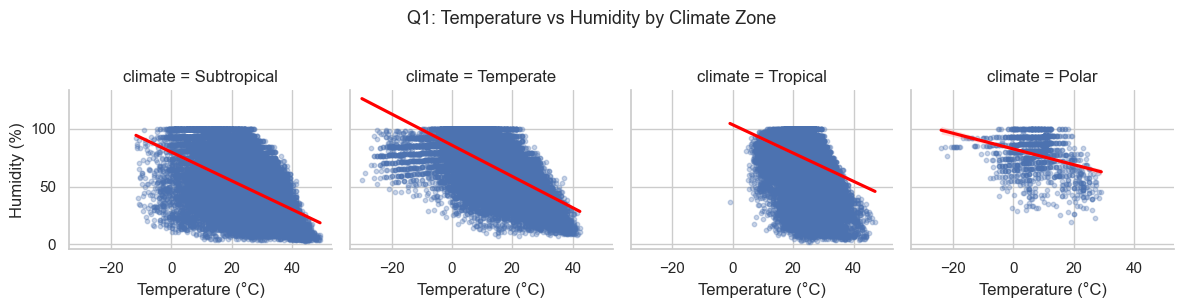

In [4]:
# Identify relevant columns
temp_col   = 'temperature_celsius'
humid_col  = 'humidity'
climate_col = 'climate' if 'climate' in df.columns else 'condition'

print('=== Q1: Pearson Correlation — Temperature vs Humidity by Climate Zone ===\n')

results = []
for zone, grp in df.groupby(climate_col):
    grp_clean = grp[[temp_col, humid_col]].dropna()
    if len(grp_clean) > 30:
        r, p = pearsonr(grp_clean[temp_col], grp_clean[humid_col])
        sig = 'YES ✅' if p < 0.05 else 'NO ❌'
        results.append({'Climate Zone': zone, 'Pearson r': round(r, 3),
                         'p-value': round(p, 4), 'Significant?': sig, 'n': len(grp_clean)})

res_df = pd.DataFrame(results).sort_values('Pearson r')
print(res_df.to_string(index=False))

# Scatter plot by climate zone
g = sns.FacetGrid(df[[temp_col, humid_col, climate_col]].dropna(),
                  col=climate_col, col_wrap=4, height=3)
g.map(sns.regplot, temp_col, humid_col, scatter_kws={'alpha':0.3, 's':10},
      line_kws={'color':'red'})
g.set_axis_labels('Temperature (°C)', 'Humidity (%)')
g.figure.suptitle('Q1: Temperature vs Humidity by Climate Zone', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
##  Q2 — Wind Speed vs Atmospheric Pressure Correlation

=== Q2: Wind Speed vs Atmospheric Pressure ===
Pearson  r = -0.0830, p = 8.1581e-190
Spearman r = -0.1544, p = 0.0000e+00


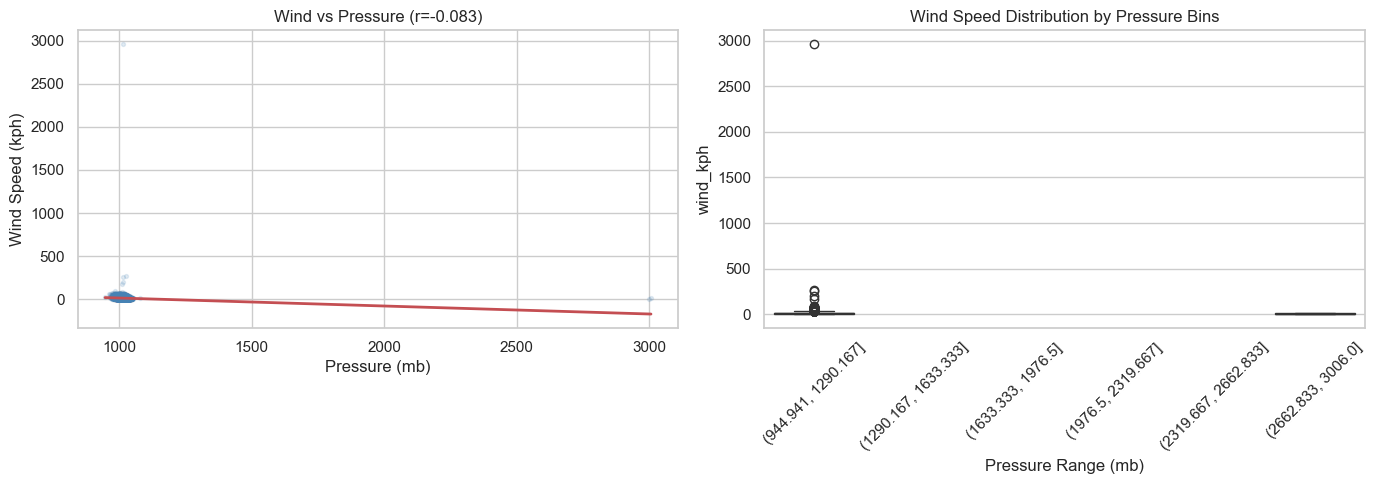

In [5]:
wind_col     = 'wind_kph'
pressure_col = 'pressure_mb'

clean = df[[wind_col, pressure_col]].dropna()
r_p, p_p = pearsonr(clean[wind_col], clean[pressure_col])
r_s, p_s = spearmanr(clean[wind_col], clean[pressure_col])

print('=== Q2: Wind Speed vs Atmospheric Pressure ===')
print(f'Pearson  r = {r_p:.4f}, p = {p_p:.4e}')
print(f'Spearman r = {r_s:.4f}, p = {p_s:.4e}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(clean[pressure_col], clean[wind_col], alpha=0.15, s=8, color='steelblue')
m, b = np.polyfit(clean[pressure_col], clean[wind_col], 1)
axes[0].plot(sorted(clean[pressure_col]), [m*x+b for x in sorted(clean[pressure_col])], 'r-', lw=2)
axes[0].set_xlabel('Pressure (mb)')
axes[0].set_ylabel('Wind Speed (kph)')
axes[0].set_title(f'Wind vs Pressure (r={r_p:.3f})')

sns.boxplot(data=df, x=pd.cut(df[pressure_col], bins=6), y=wind_col, ax=axes[1], palette='Blues')
axes[1].set_title('Wind Speed Distribution by Pressure Bins')
axes[1].set_xlabel('Pressure Range (mb)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
##  Q4 — Global Monthly Temperature Shift Over Time

=== Q4: Global Monthly Temperature Trend ===
Slope: -0.34472 °C per month | p-value: 5.3593e-03
Overall trend: COOLING ↓


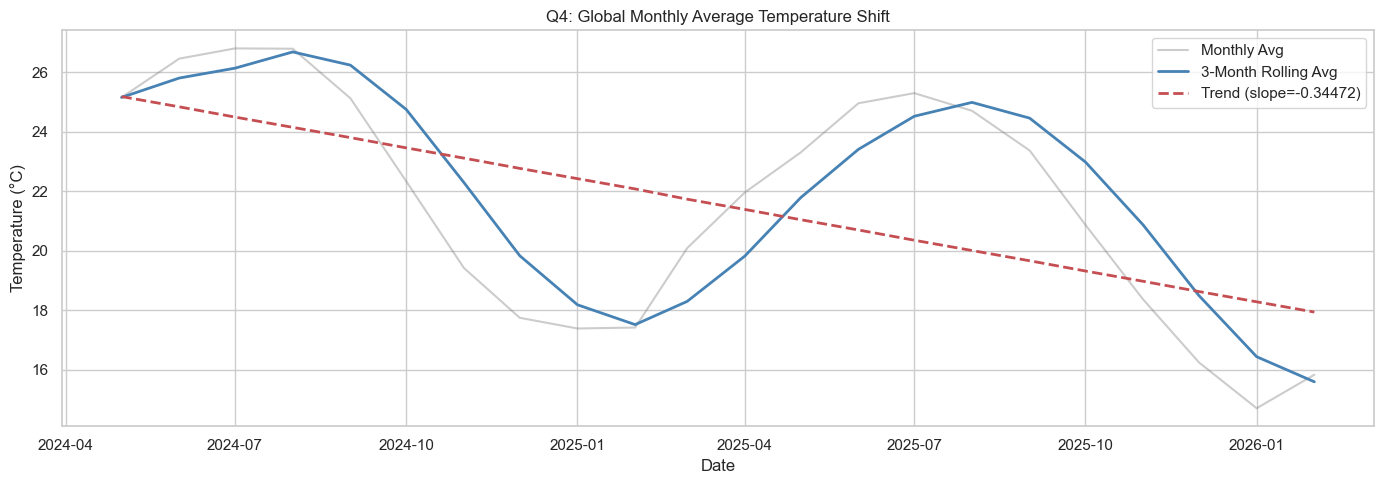

In [6]:
monthly_avg = df.groupby(['year', 'month'])[temp_col].mean().reset_index()
monthly_avg['year_month'] = pd.to_datetime(
    monthly_avg['year'].astype(str) + '-' + monthly_avg['month'].astype(str).str.zfill(2))
monthly_avg = monthly_avg.sort_values('year_month')

# Rolling average
monthly_avg['rolling_avg'] = monthly_avg[temp_col].rolling(window=3, min_periods=1).mean()

# Trend line
x_num = np.arange(len(monthly_avg))
slope, intercept, r, p, se = stats.linregress(x_num, monthly_avg[temp_col].fillna(method='ffill'))
trend = slope * x_num + intercept

print(f'=== Q4: Global Monthly Temperature Trend ===')
print(f'Slope: {slope:.5f} °C per month | p-value: {p:.4e}')
print(f'Overall trend: {"WARMING ↑" if slope > 0 else "COOLING ↓"}')

plt.figure(figsize=(14, 5))
plt.plot(monthly_avg['year_month'], monthly_avg[temp_col], alpha=0.4, label='Monthly Avg', color='gray')
plt.plot(monthly_avg['year_month'], monthly_avg['rolling_avg'], label='3-Month Rolling Avg', color='steelblue', lw=2)
plt.plot(monthly_avg['year_month'], trend, 'r--', lw=2, label=f'Trend (slope={slope:.5f})')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Q4: Global Monthly Average Temperature Shift')
plt.legend()
plt.tight_layout()
plt.show()

---
## ❓ Q5 — Seasonal Precipitation Patterns: Northern vs Southern Hemisphere

=== Q5: Average Precipitation by Hemisphere and Season ===
hemisphere  Northern  Southern
season                        
Autumn          0.14      0.13
Spring          0.11      0.23
Summer          0.18      0.07
Winter          0.08      0.24


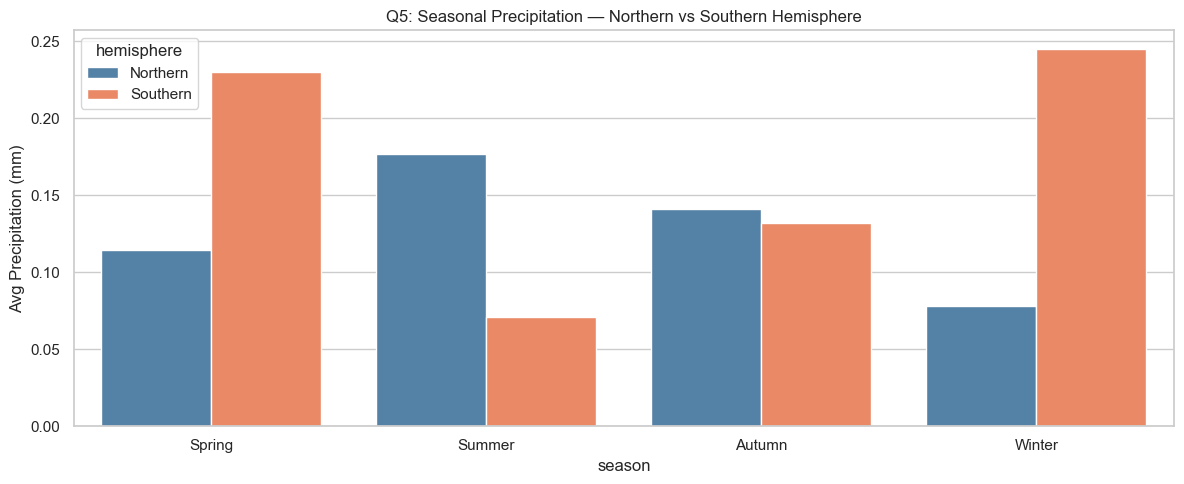

In [8]:
lat_col = 'latitude'
precip_col='precip_mm'
if lat_col in df.columns:
    df['hemisphere'] = df[lat_col].apply(lambda x: 'Northern' if x >= 0 else 'Southern')
else:
    # fallback: use country-based manual mapping
    southern = ['Australia','Brazil','Argentina','South Africa','New Zealand','Chile','Peru']
    df['hemisphere'] = df['country'].apply(lambda x: 'Southern' if x in southern else 'Northern')

season_map = {12:'Winter', 1:'Winter', 2:'Winter',
              3:'Spring',  4:'Spring',  5:'Spring',
              6:'Summer',  7:'Summer',  8:'Summer',
              9:'Autumn', 10:'Autumn', 11:'Autumn'}
df['season'] = df['month'].map(season_map)

seasonal = df.groupby(['hemisphere', 'season'])[precip_col].mean().reset_index()
print('=== Q5: Average Precipitation by Hemisphere and Season ===')
print(seasonal.pivot(index='season', columns='hemisphere', values=precip_col).round(2))

order = ['Spring', 'Summer', 'Autumn', 'Winter']
sns.barplot(data=seasonal, x='season', y=precip_col, hue='hemisphere',
            order=order, palette={'Northern': 'steelblue', 'Southern': 'coral'})
plt.title('Q5: Seasonal Precipitation — Northern vs Southern Hemisphere')
plt.ylabel('Avg Precipitation (mm)')
plt.tight_layout()
plt.show()

=== Q6: Top 15 Countries by Average Diurnal Temperature Range ===
country
Bolivia                         10.68
USA United States of America    10.00
Iran                             5.74
Indonesia                        4.21
Madagascar                       4.08
Bulgaria                         3.62
Turkey                           3.33
Sudan                            3.24
Vietnam                          2.93
Thailand                         2.57
Belgium                          1.05
Russia                           0.80
Switzerland                      0.64
Hungary                          0.13
Australia                        0.05
Name: diurnal_range, dtype: float64


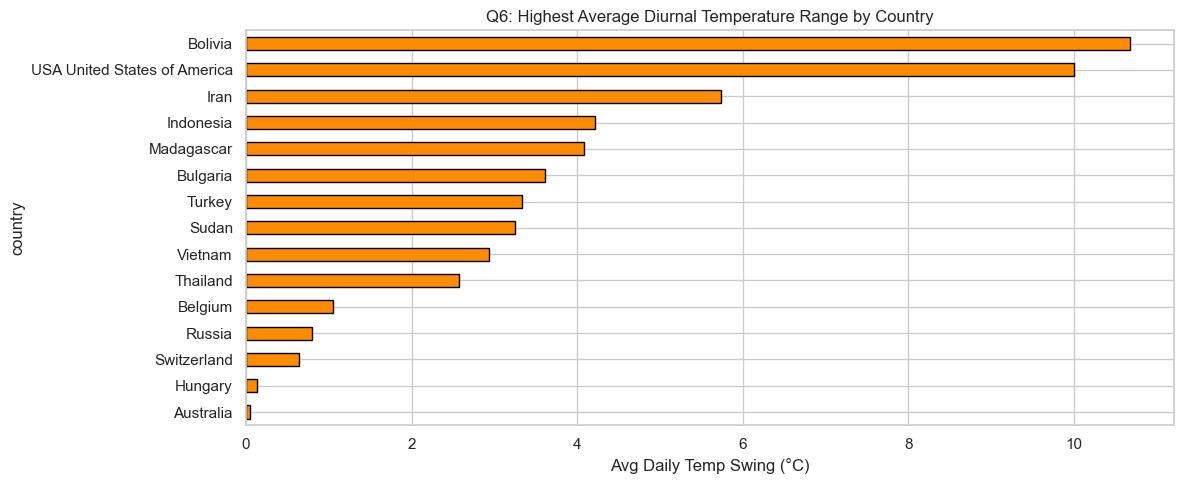

In [9]:
max_col = 'maxtemp_c' if 'maxtemp_c' in df.columns else None
min_col = 'mintemp_c' if 'mintemp_c' in df.columns else None

if max_col and min_col:
    df['diurnal_range'] = df[max_col] - df[min_col]
else:
    # Approximate: per-country daily max - min of temperature_celsius
    df['date_str'] = df[date_col].dt.date.astype(str)
    diurnal = df.groupby(['country', 'date_str'])[temp_col].agg(['max','min'])
    diurnal['diurnal_range'] = diurnal['max'] - diurnal['min']
    diurnal = diurnal.reset_index()
    df = df.merge(diurnal[['country','date_str','diurnal_range']],
                  on=['country','date_str'], how='left')

top_diurnal = df.groupby('country')['diurnal_range'].mean().sort_values(ascending=False).head(15)
print('=== Q6: Top 15 Countries by Average Diurnal Temperature Range ===')
print(top_diurnal.round(2))

top_diurnal.plot(kind='barh', color='darkorange', edgecolor='black')
plt.title('Q6: Highest Average Diurnal Temperature Range by Country')
plt.xlabel('Avg Daily Temp Swing (°C)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

=== Q7: Wind Speed by Climate Zone ===
             Mean Wind (kph)  Median Wind (kph)  Std Dev
climate                                                 
Polar                  20.76               18.4    12.36
Subtropical            13.38               11.5     8.20
Tropical               12.94               10.8    14.56
Temperate              12.43               10.4     8.16


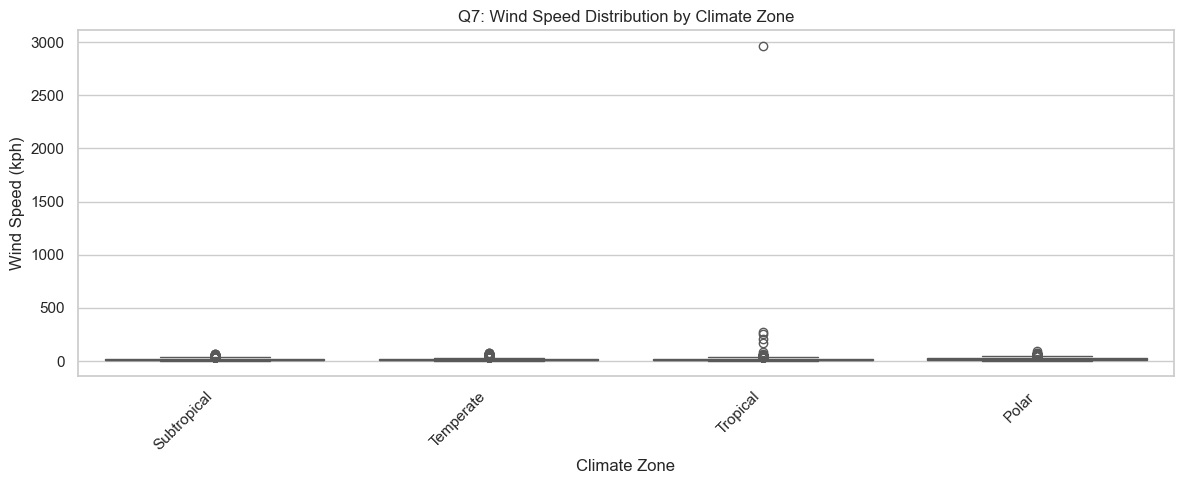

In [10]:
# Use climate/condition column to classify zone type, or latitude bins
if climate_col in df.columns:
    zone_wind = df.groupby(climate_col)[wind_col].agg(['mean','median','std']).round(2)
    zone_wind.columns = ['Mean Wind (kph)', 'Median Wind (kph)', 'Std Dev']
    zone_wind = zone_wind.sort_values('Mean Wind (kph)', ascending=False)
    print('=== Q7: Wind Speed by Climate Zone ===')
    print(zone_wind)

    sns.boxplot(data=df, x=climate_col, y=wind_col, palette='Set2')
    plt.title('Q7: Wind Speed Distribution by Climate Zone')
    plt.xlabel('Climate Zone')
    plt.ylabel('Wind Speed (kph)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Climate zone column not found. Grouping by latitude bins.')
    df['lat_zone'] = pd.cut(df[lat_col], bins=[-90,-45,-23,0,23,45,90],
                             labels=['S-Polar','S-Temp','Tropics-S','Tropics-N','N-Temp','N-Polar'])
    sns.boxplot(data=df, x='lat_zone', y=wind_col, palette='Set3')
    plt.title('Q7: Wind Speed by Latitude Zone')
    plt.tight_layout()
    plt.show()

=== Q8: Top 15 Countries with Fastest Temperature Increase (°C/year) ===
country
Solomon Islands             1.3669
Palau                       0.8777
Micronesia                  0.8335
Gabon                      -0.9569
Benin                      -1.0950
Uganda                     -1.4098
Liberia                    -1.5325
Jamaica                    -1.6139
Antigua and Barbuda        -1.8847
Saint Kitts and Nevis      -1.9190
Burundi                    -2.0558
Cape Verde                 -3.1863
Central African Republic   -3.4791
Gambia                     -3.7392
Guinea-Bissau              -3.9689
dtype: float64


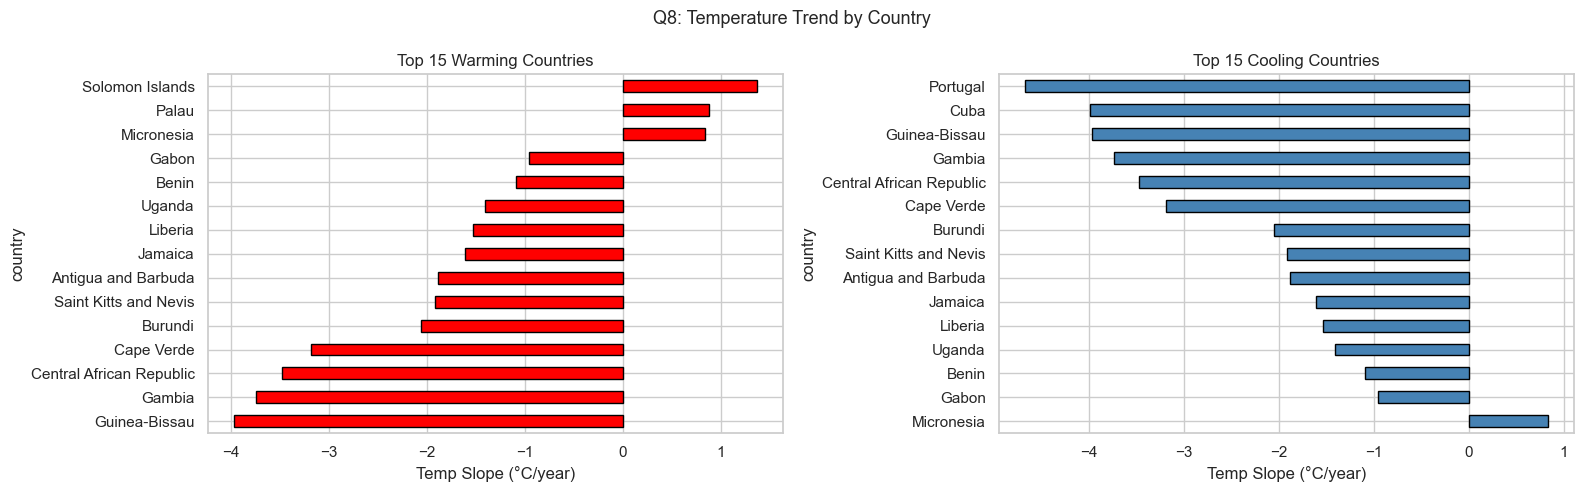

In [11]:
from scipy.stats import linregress

yearly_country = df.groupby(['country', 'year'])[temp_col].mean().reset_index()

def compute_slope(grp):
    if len(grp) < 3:
        return np.nan
    s, _, _, p, _ = linregress(grp['year'], grp[temp_col])
    return s if p < 0.05 else np.nan

slopes = yearly_country.groupby('country').apply(compute_slope).dropna()
slopes = slopes.sort_values(ascending=False)

print('=== Q8: Top 15 Countries with Fastest Temperature Increase (°C/year) ===')
print(slopes.head(15).round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

slopes.head(15).plot(kind='barh', ax=axes[0], color='red', edgecolor='black')
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Warming Countries')
axes[0].set_xlabel('Temp Slope (°C/year)')

slopes.tail(15).sort_values().plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Cooling Countries')
axes[1].set_xlabel('Temp Slope (°C/year)')

plt.suptitle('Q8: Temperature Trend by Country', fontsize=13)
plt.tight_layout()
plt.show()

=== Q9: High-Precipitation Zones (top 10% threshold = 0.37 mm) ===
                         country  month  precip_mm
Lao People's Democratic Republic      6   1.970000
                         Letonia      7   1.830000
                    Sierra Leone      7   1.675593
                         Malásia      7   1.550000
                          Guinea      7   1.486000
                Papua New Guinea      3   1.408065
                          Guinea      8   1.380000
                   Guinea-Bissau      7   1.350833
                    Sierra Leone      9   1.250000
                    Sierra Leone      8   1.228548
                         Myanmar      7   1.190833
                           Nepal      7   1.132542
                Papua New Guinea      4   1.082333
                     El Salvador      6   1.057797
                 Solomon Islands      1   1.041311
                       Indonesia      1   1.037541
                        Malaysia      4   0.983333
               

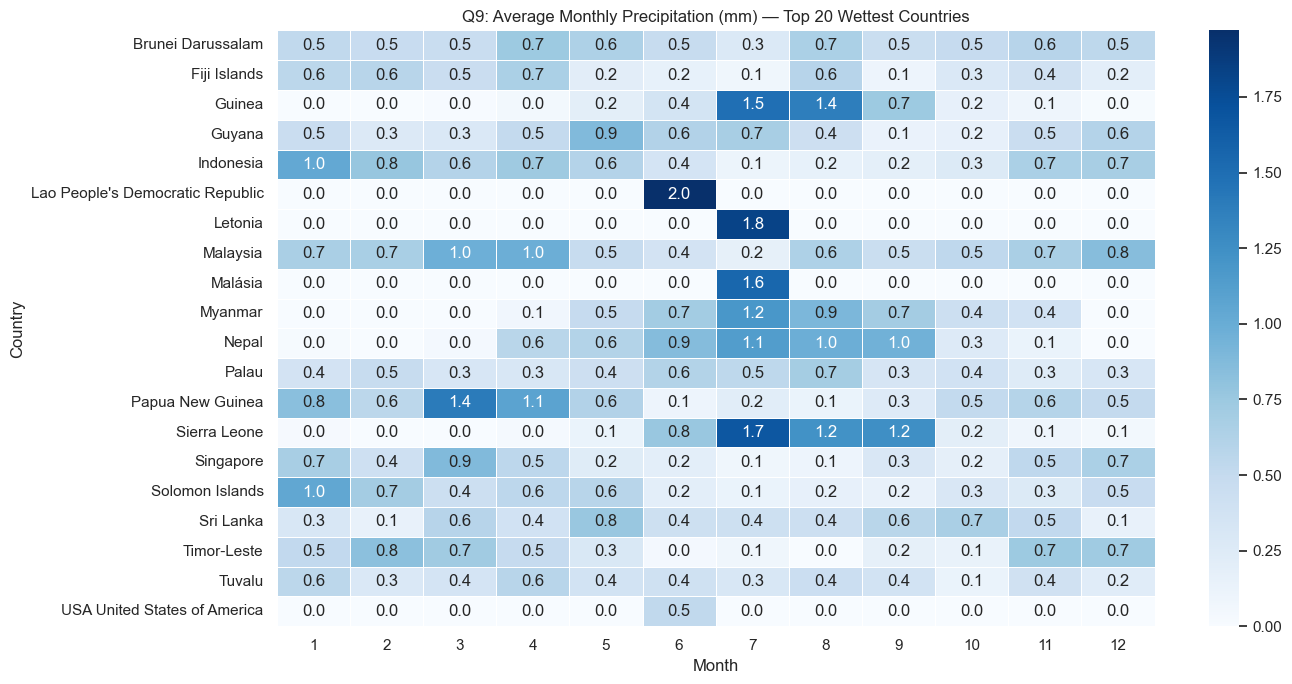

In [12]:
monthly_precip = df.groupby(['country', 'month'])[precip_col].mean().reset_index()
threshold_95 = monthly_precip[precip_col].quantile(0.90)
high_zones = monthly_precip[monthly_precip[precip_col] >= threshold_95].sort_values(precip_col, ascending=False)

print(f'=== Q9: High-Precipitation Zones (top 10% threshold = {threshold_95:.2f} mm) ===')
print(high_zones.head(20).to_string(index=False))

pivot = monthly_precip.pivot_table(index='country', columns='month', values=precip_col)
top_countries = monthly_precip.groupby('country')[precip_col].mean().nlargest(20).index
pivot_top = pivot.loc[pivot.index.isin(top_countries)].fillna(0)

plt.figure(figsize=(14, 7))
sns.heatmap(pivot_top, cmap='Blues', annot=True, fmt='.1f', linewidths=0.5)
plt.title('Q9: Average Monthly Precipitation (mm) — Top 20 Wettest Countries')
plt.xlabel('Month')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

=== Q10: Top 1% Extreme Wind Events (threshold: 37.4 kph) ===
Total extreme events: 1273
              country        last_updated  wind_kph  temperature_celsius  pressure_mb
              Burundi 2024-06-23 15:45:00    2963.2                 22.5         1014
             Ethiopia 2024-06-21 16:30:00     272.2                 22.3         1025
              Burundi 2024-05-21 16:45:00     258.8                 30.0         1013
Saint Kitts and Nevis 2024-06-28 09:15:00     205.9                 31.1         1016
         Fiji Islands 2024-05-20 02:00:00     172.1                 26.0         1011
              Iceland 2025-02-06 10:15:00      91.1                  8.0          983
             Barbados 2024-07-01 09:15:00      81.0                 26.3         1010
               Norway 2024-08-27 14:15:00      78.1                 14.4         1004
              Iceland 2024-11-15 09:00:00      76.7                  3.3          987
              Iceland 2024-12-25 10:15:00      76.0

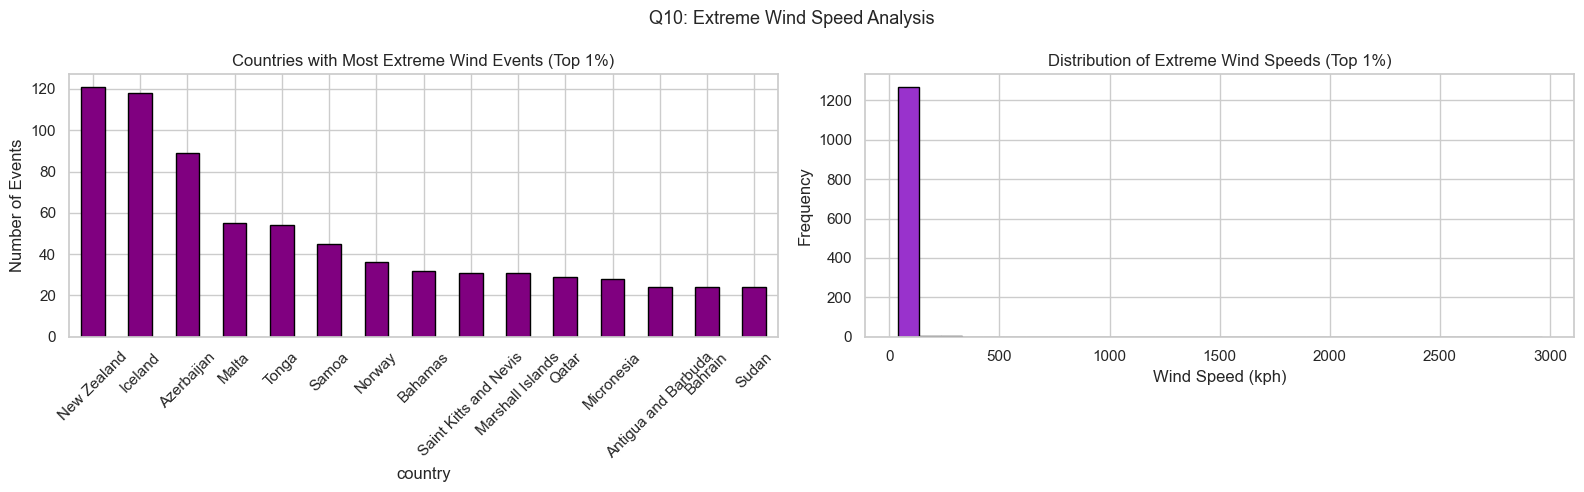

In [13]:
wind_99 = df[wind_col].quantile(0.99)
extreme_wind = df[df[wind_col] >= wind_99][['country', date_col, wind_col, temp_col, pressure_col]].copy()
extreme_wind = extreme_wind.sort_values(wind_col, ascending=False)

print(f'=== Q10: Top 1% Extreme Wind Events (threshold: {wind_99:.1f} kph) ===')
print(f'Total extreme events: {len(extreme_wind)}')
print(extreme_wind.head(20).to_string(index=False))

top_countries_wind = extreme_wind['country'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_countries_wind.plot(kind='bar', ax=axes[0], color='purple', edgecolor='black')
axes[0].set_title('Countries with Most Extreme Wind Events (Top 1%)')
axes[0].set_ylabel('Number of Events')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(extreme_wind[wind_col], bins=30, color='darkorchid', edgecolor='black')
axes[1].set_title('Distribution of Extreme Wind Speeds (Top 1%)')
axes[1].set_xlabel('Wind Speed (kph)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Q10: Extreme Wind Speed Analysis', fontsize=13)
plt.tight_layout()
plt.show()

=== Q11: Temperature Anomalies (|z| > 2σ) ===
Total anomaly events: 4177
       last_updated                  country  temperature_celsius  z_score  anomaly_type
2024-05-17 11:00:00                  Ecuador                 18.9 5.537431 Extreme Hot 🔥
2024-06-12 10:15:00                 Dominica                 35.3 4.743383 Extreme Hot 🔥
2024-06-25 09:15:00 United States of America                 26.1 4.448794 Extreme Hot 🔥
2024-06-03 09:15:00                  Ecuador                 17.1 4.359272 Extreme Hot 🔥
2024-05-22 11:15:00                 Suriname                 32.0 4.332560 Extreme Hot 🔥
2024-05-20 09:30:00                  Ecuador                 16.9 4.228365 Extreme Hot 🔥
2025-12-31 18:00:00          Solomon Islands                 34.3 4.064482 Extreme Hot 🔥
2024-05-18 10:30:00                 Dominica                 34.0 4.025785 Extreme Hot 🔥
2024-05-17 10:00:00                Guatemala                 25.0 4.018136 Extreme Hot 🔥
2024-05-25 09:00:00                  

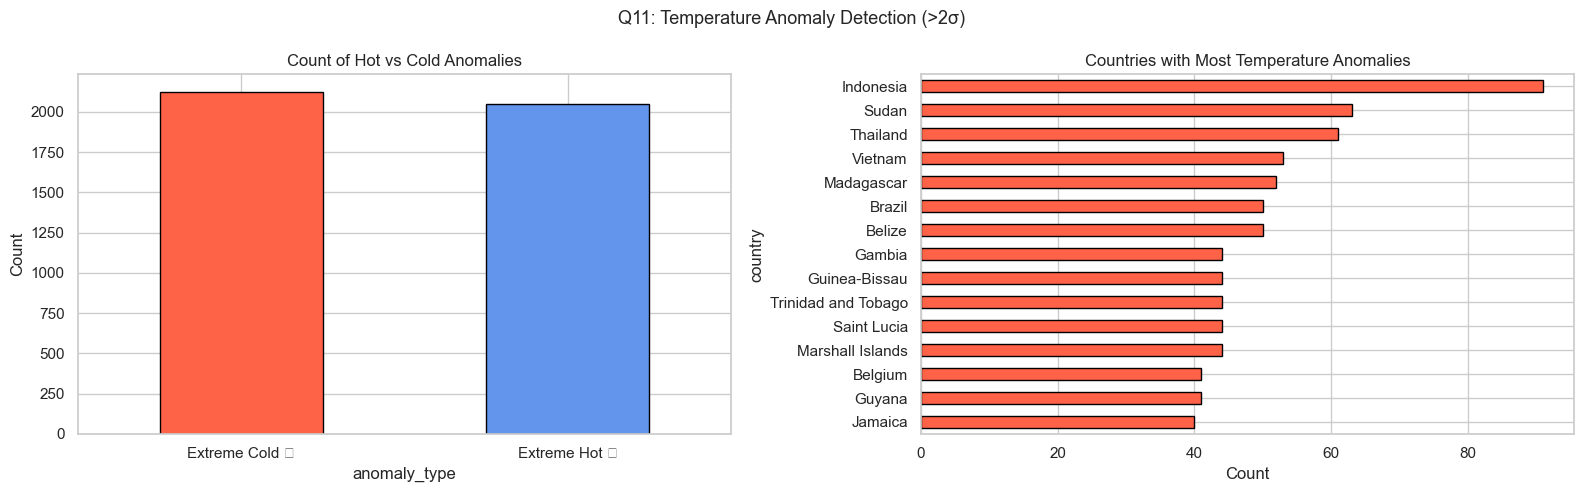

In [14]:
region_stats = df.groupby('country')[temp_col].agg(['mean','std']).reset_index()
region_stats.columns = ['country', 'region_mean', 'region_std']
df2 = df.merge(region_stats, on='country', how='left')
df2['z_score'] = (df2[temp_col] - df2['region_mean']) / df2['region_std']

anomalies = df2[np.abs(df2['z_score']) > 2][[date_col, 'country', temp_col, 'z_score']].copy()
anomalies['anomaly_type'] = anomalies['z_score'].apply(lambda z: 'Extreme Hot 🔥' if z > 2 else 'Extreme Cold 🥶')
anomalies = anomalies.sort_values('z_score', ascending=False)

print(f'=== Q11: Temperature Anomalies (|z| > 2σ) ===')
print(f'Total anomaly events: {len(anomalies)}')
print(anomalies.head(20).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
anomalies['anomaly_type'].value_counts().plot(kind='bar', ax=axes[0],
    color=['tomato','cornflowerblue'], edgecolor='black')
axes[0].set_title('Count of Hot vs Cold Anomalies')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

anomalies['country'].value_counts().head(15).plot(kind='barh', ax=axes[1],
    color='tomato', edgecolor='black')
axes[1].invert_yaxis()
axes[1].set_title('Countries with Most Temperature Anomalies')
axes[1].set_xlabel('Count')

plt.suptitle('Q11: Temperature Anomaly Detection (>2σ)', fontsize=13)
plt.tight_layout()
plt.show()

=== Q12: Flash Precipitation Events (>2σ above seasonal mean) ===
Total flash events: 4108
       last_updated    country season  precip_mm  precip_z
2024-06-03 17:15:00   Bulgaria Summer      18.90 17.293666
2024-07-04 16:15:00     Turkey Summer       6.12 17.080599
2024-08-31 15:00:00 Madagascar Summer       1.49 16.891634
2025-12-13 14:15:00    Vietnam Winter       3.71 16.542394
2024-11-23 12:00:00     Turkey Autumn       5.56 16.464520
2025-10-02 09:00:00      Sudan Autumn       1.10 16.026525
2024-11-11 12:30:00       Iran Autumn       1.89 15.385100
2025-09-05 04:00:00    Bolivia Autumn       5.30 14.813263
2025-10-03 09:45:00   Bulgaria Autumn       6.38 14.508033
2024-09-07 19:00:00    Vietnam Autumn      27.82 14.301968
2025-12-14 14:15:00   Thailand Winter       0.41 13.934920
2025-08-27 10:00:00      Sudan Summer       4.81 13.684516
2025-06-17 05:00:00    Bolivia Summer       1.53 13.458116
2025-06-06 11:45:00   Tanzania Summer       0.01 13.416613
2025-11-15 10:30:00     

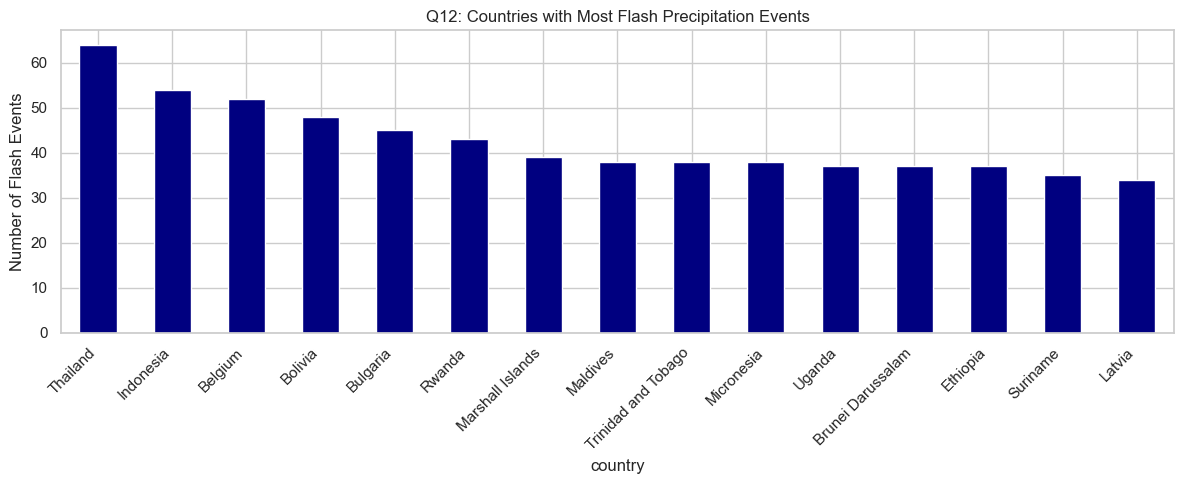

In [15]:
season_precip = df.groupby(['country', 'season'])[precip_col].agg(['mean','std']).reset_index()
season_precip.columns = ['country','season','season_mean','season_std']
df3 = df.merge(season_precip, on=['country','season'], how='left')
df3['precip_z'] = (df3[precip_col] - df3['season_mean']) / df3['season_std'].replace(0, np.nan)

flash = df3[df3['precip_z'] > 2][[date_col, 'country', 'season', precip_col, 'precip_z']].dropna()
flash = flash.sort_values('precip_z', ascending=False)

print('=== Q12: Flash Precipitation Events (>2σ above seasonal mean) ===')
print(f'Total flash events: {len(flash)}')
print(flash.head(20).to_string(index=False))

flash['country'].value_counts().head(15).plot(kind='bar', color='navy', edgecolor='white')
plt.title('Q12: Countries with Most Flash Precipitation Events')
plt.ylabel('Number of Flash Events')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== Q13: Climate Zones with Inverse (Negative) Temp-Humidity Correlation ===
Climate Zone  Pearson r  p-value Significant?     n
   Temperate     -0.651      0.0        YES ✅ 32268
 Subtropical     -0.488      0.0        YES ✅ 29282
       Polar     -0.331      0.0        YES ✅  1283
    Tropical     -0.276      0.0        YES ✅ 62083

Interpretation:
  Negative r → As temperature rises, humidity drops.
  This is the hallmark of DRY HEAT zones (arid, semi-arid deserts).
  Hot air expands and reduces relative humidity — no moisture source nearby.

Positive r → HUMID HEAT zones (tropical, equatorial).
  Warm air holds more moisture and evaporation keeps humidity high.


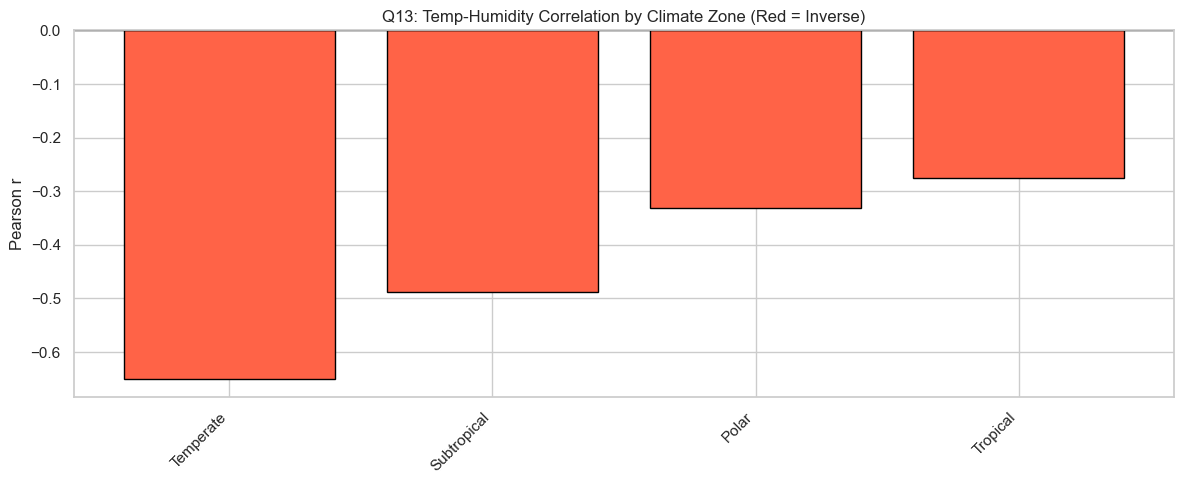

In [16]:
print('=== Q13: Climate Zones with Inverse (Negative) Temp-Humidity Correlation ===')
inverse_zones = res_df[res_df['Pearson r'] < 0].copy()
print(inverse_zones.to_string(index=False))
print()
print('Interpretation:')
print('  Negative r → As temperature rises, humidity drops.')
print('  This is the hallmark of DRY HEAT zones (arid, semi-arid deserts).')
print('  Hot air expands and reduces relative humidity — no moisture source nearby.')
print()
print('Positive r → HUMID HEAT zones (tropical, equatorial).')
print('  Warm air holds more moisture and evaporation keeps humidity high.')

# Visualize
res_df_plot = res_df.copy().reset_index(drop=True)
colors = ['tomato' if r < 0 else 'steelblue' for r in res_df_plot['Pearson r']]
plt.bar(res_df_plot['Climate Zone'], res_df_plot['Pearson r'], color=colors, edgecolor='black')
plt.axhline(0, color='black', lw=1)
plt.title('Q13: Temp-Humidity Correlation by Climate Zone (Red = Inverse)')
plt.ylabel('Pearson r')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


=== Q14: Pressure Drop vs Next-Period Wind Speed ===
Overall: r = 0.0099, p = 4.9747e-04
Interpretation: Pressure drop DOES predict wind increase ✅
       Zone      r      p     n
      Polar  0.248 0.0000  1281
  Temperate  0.086 0.0000 32214
Subtropical  0.002 0.6782 29229
   Tropical -0.000 0.9623 61981


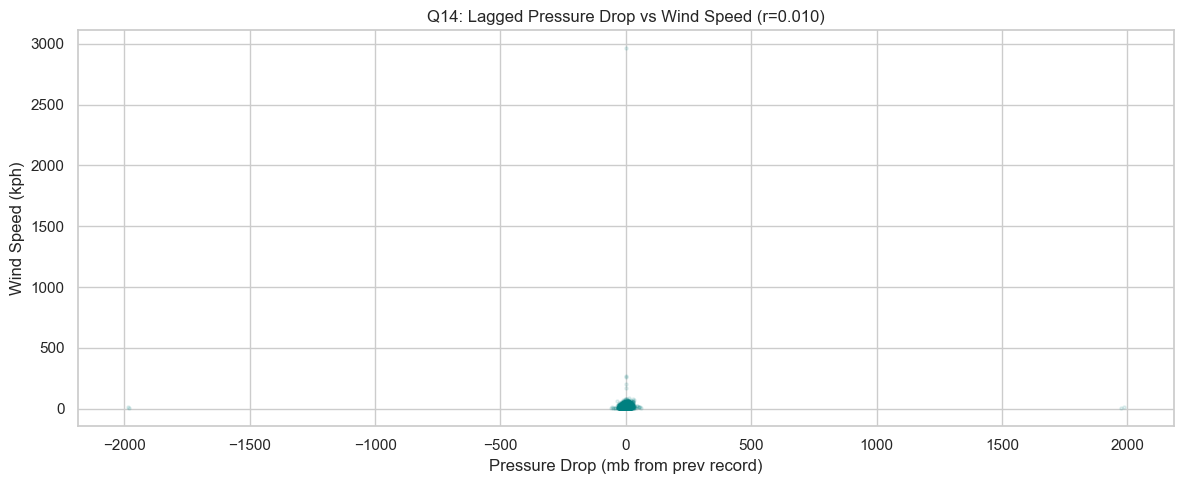

In [17]:
# Sort by country and date, compute lagged pressure
df_lag = df.sort_values([date_col]).copy()
df_lag['pressure_lag1'] = df_lag.groupby('country')[pressure_col].shift(1)
df_lag['pressure_drop'] = df_lag['pressure_lag1'] - df_lag[pressure_col]  # positive = drop
df_lag = df_lag.dropna(subset=['pressure_drop', wind_col])

r_all, p_all = pearsonr(df_lag['pressure_drop'], df_lag[wind_col])
print(f'=== Q14: Pressure Drop vs Next-Period Wind Speed ===')
print(f'Overall: r = {r_all:.4f}, p = {p_all:.4e}')
print(f'Interpretation: {"Pressure drop DOES predict wind increase ✅" if r_all > 0 and p_all < 0.05 else "No strong predictive link ❌"}')

# Split coastal vs inland if climate info available
if climate_col in df_lag.columns:
    results_lag = []
    for zone, grp in df_lag.groupby(climate_col):
        g = grp.dropna(subset=['pressure_drop', wind_col])
        if len(g) > 50:
            r, p = pearsonr(g['pressure_drop'], g[wind_col])
            results_lag.append({'Zone': zone, 'r': round(r,3), 'p': round(p,4), 'n': len(g)})
    print(pd.DataFrame(results_lag).sort_values('r', ascending=False).to_string(index=False))

plt.scatter(df_lag['pressure_drop'], df_lag[wind_col], alpha=0.1, s=5, color='teal')
plt.xlabel('Pressure Drop (mb from prev record)')
plt.ylabel('Wind Speed (kph)')
plt.title(f'Q14: Lagged Pressure Drop vs Wind Speed (r={r_all:.3f})')
plt.tight_layout()
plt.show()

=== Q15: Countries with High Humidity but Low Rainfall (High Ratio) ===
             country  avg_humidity  avg_precip  humidity_precip_ratio
           Гватемала         95.00         0.0                9500.00
               Libya         74.00         0.0                7400.00
             Mexique         72.00         0.0                7200.00
             Komoren         71.00         0.0                7100.00
                Inde         71.00         0.0                7100.00
             Estonie         61.00         0.0                6100.00
                Peru         84.09         0.0                6059.16
              Польша         56.00         0.0                5600.00
             Polônia         52.00         0.0                5200.00
                Oman         52.12         0.0                4699.86
              Турция         44.00         0.0                4400.00
United Arab Emirates         43.01         0.0                4189.98
             Bahra

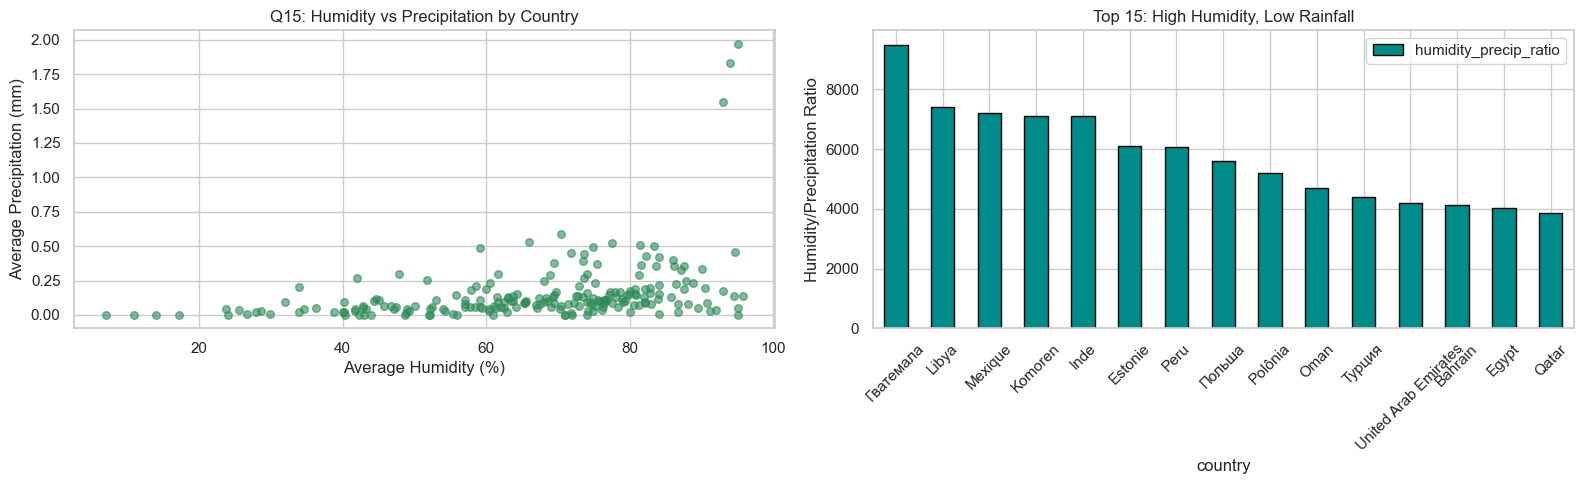

In [18]:
ratio_df = df.groupby('country').agg(
    avg_humidity=(humid_col, 'mean'),
    avg_precip=(precip_col, 'mean')
).reset_index().dropna()

ratio_df['humidity_precip_ratio'] = ratio_df['avg_humidity'] / (ratio_df['avg_precip'] + 0.01)

# High humidity, low rainfall = high ratio
top_ratio = ratio_df.sort_values('humidity_precip_ratio', ascending=False).head(15)

print('=== Q15: Countries with High Humidity but Low Rainfall (High Ratio) ===')
print(top_ratio[['country','avg_humidity','avg_precip','humidity_precip_ratio']].round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].scatter(ratio_df['avg_humidity'], ratio_df['avg_precip'],
                alpha=0.6, s=30, color='seagreen')
axes[0].set_xlabel('Average Humidity (%)')
axes[0].set_ylabel('Average Precipitation (mm)')
axes[0].set_title('Q15: Humidity vs Precipitation by Country')

top_ratio.plot(x='country', y='humidity_precip_ratio', kind='bar',
               ax=axes[1], color='darkcyan', edgecolor='black')
axes[1].set_title('Top 15: High Humidity, Low Rainfall')
axes[1].set_ylabel('Humidity/Precipitation Ratio')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

=== Q16: Compound Extremes (Temp ≥ 31.2°C AND Wind ≥ 24.8 kph) ===
Total compound extreme events: 1233
As % of all records: 0.99%

Compound Extremes per Year:
 year  compound_extreme
 2024               617
 2025               605
 2026                11


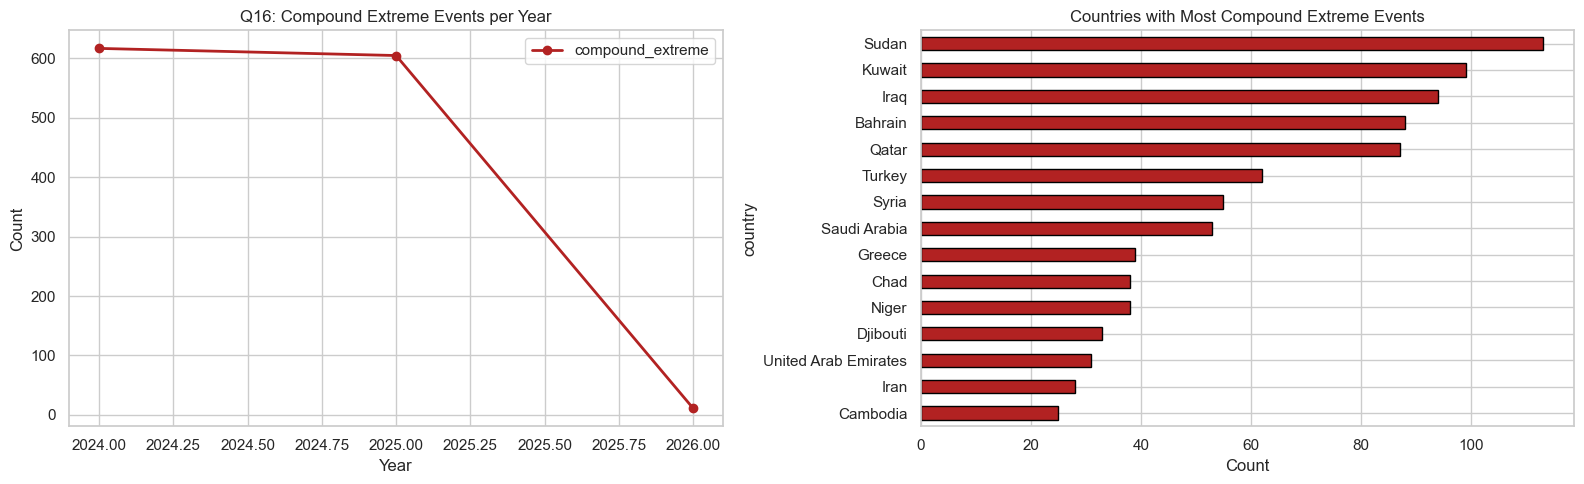

In [19]:
heat_thresh = df[temp_col].quantile(0.90)
wind_thresh = df[wind_col].quantile(0.90)

df['compound_extreme'] = ((df[temp_col] >= heat_thresh) & (df[wind_col] >= wind_thresh)).astype(int)

print(f'=== Q16: Compound Extremes (Temp ≥ {heat_thresh:.1f}°C AND Wind ≥ {wind_thresh:.1f} kph) ===')
print(f'Total compound extreme events: {df["compound_extreme"].sum()}')
print(f'As % of all records: {df["compound_extreme"].mean()*100:.2f}%')

yearly_compound = df.groupby('year')['compound_extreme'].sum().reset_index()
print('\nCompound Extremes per Year:')
print(yearly_compound.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
yearly_compound.plot(x='year', y='compound_extreme', ax=axes[0],
                     marker='o', color='firebrick', lw=2)
axes[0].set_title('Q16: Compound Extreme Events per Year')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Year')

df.groupby('country')['compound_extreme'].sum().nlargest(15).plot(
    kind='barh', ax=axes[1], color='firebrick', edgecolor='black')
axes[1].invert_yaxis()
axes[1].set_title('Countries with Most Compound Extreme Events')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

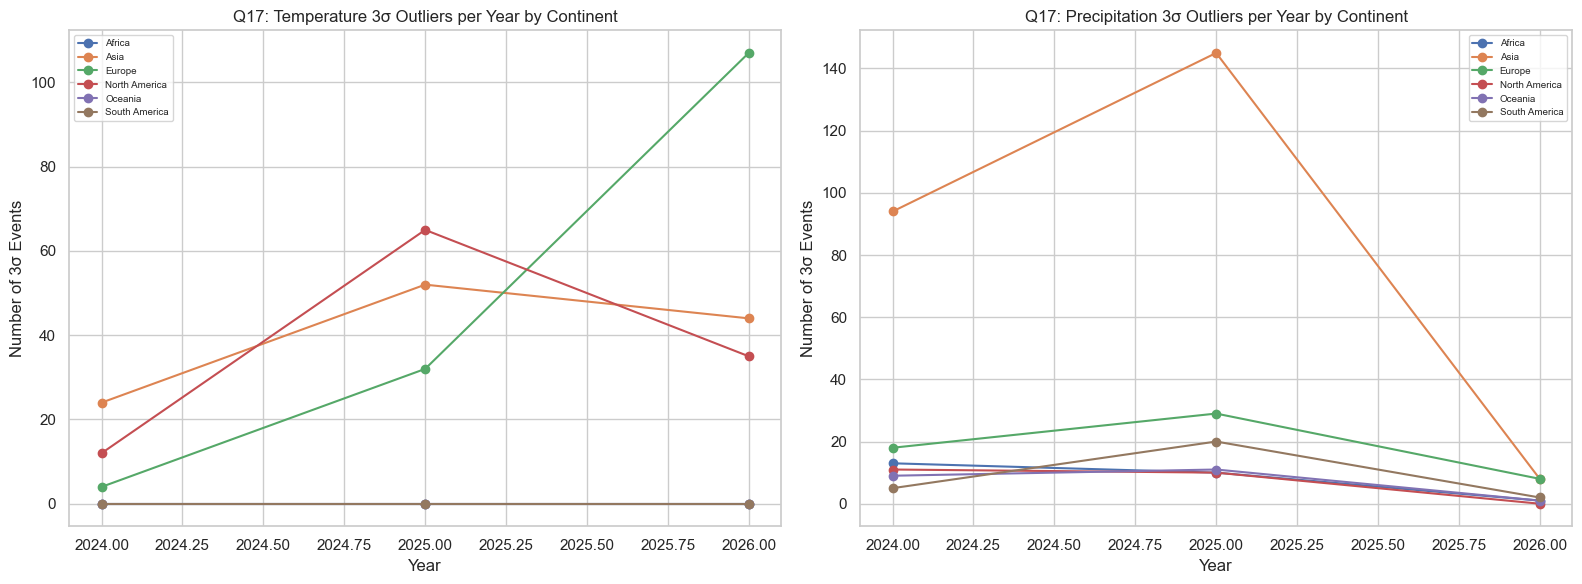

In [20]:
# Map countries to continents
continent_map = {
    'United States':'North America','Canada':'North America','Mexico':'North America',
    'Brazil':'South America','Argentina':'South America','Colombia':'South America','Peru':'South America','Chile':'South America',
    'United Kingdom':'Europe','Germany':'Europe','France':'Europe','Italy':'Europe','Spain':'Europe',
    'Russia':'Europe','Poland':'Europe','Netherlands':'Europe','Sweden':'Europe','Norway':'Europe','Turkey':'Europe',
    'China':'Asia','India':'Asia','Japan':'Asia','South Korea':'Asia','Indonesia':'Asia',
    'Pakistan':'Asia','Bangladesh':'Asia','Thailand':'Asia','Vietnam':'Asia','Philippines':'Asia',
    'Saudi Arabia':'Asia','Iran':'Asia','Iraq':'Asia','Afghanistan':'Asia','Kazakhstan':'Asia',
    'Nigeria':'Africa','South Africa':'Africa','Egypt':'Africa','Kenya':'Africa','Ethiopia':'Africa',
    'Ghana':'Africa','Tanzania':'Africa','Algeria':'Africa','Morocco':'Africa',
    'Australia':'Oceania','New Zealand':'Oceania'
}
df['continent'] = df['country'].map(continent_map).fillna('Other')

# Compute 3σ outliers per year per continent
global_temp_mean = df[temp_col].mean()
global_temp_std  = df[temp_col].std()
global_prec_mean = df[precip_col].mean()
global_prec_std  = df[precip_col].std()

df['temp_outlier']  = (np.abs(df[temp_col]  - global_temp_mean) > 3 * global_temp_std).astype(int)
df['prec_outlier']  = (np.abs(df[precip_col] - global_prec_mean) > 3 * global_prec_std).astype(int)

outlier_trend = df.groupby(['continent','year'])[['temp_outlier','prec_outlier']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col, title in zip(axes, ['temp_outlier','prec_outlier'],
                           ['Temperature 3σ Outliers','Precipitation 3σ Outliers']):
    for cont, grp in outlier_trend.groupby('continent'):
        if cont == 'Other': continue
        ax.plot(grp['year'], grp[col], marker='o', label=cont)
    ax.set_title(f'Q17: {title} per Year by Continent')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of 3σ Events')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

=== Q18: Recovery Time After Extreme Temperature Events ===
Average recovery time: ~nan records (proxy for days)


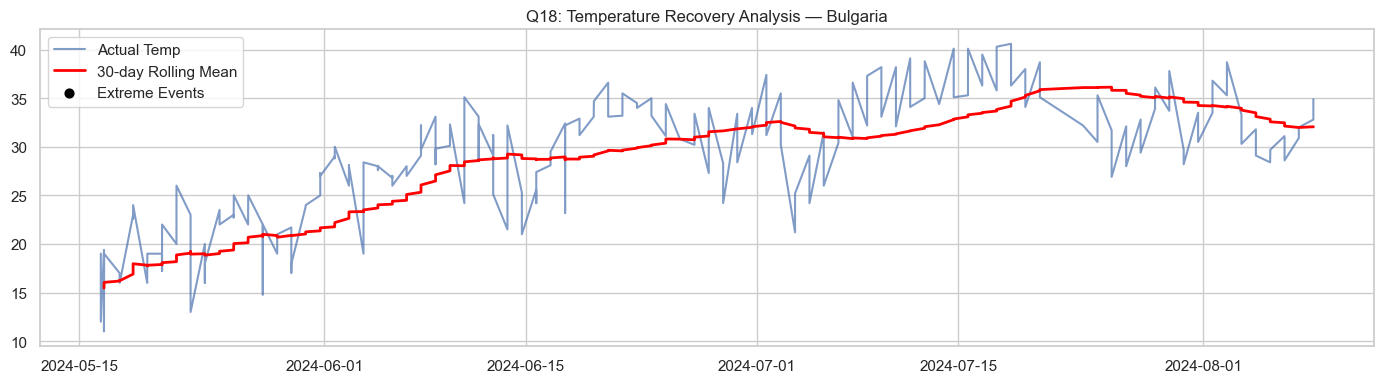

In [21]:
# Compute 30-day rolling mean per country
df_sorted = df.sort_values([date_col]).copy()
df_sorted['rolling_mean_30'] = df_sorted.groupby('country')[temp_col].transform(
    lambda x: x.rolling(window=30, min_periods=5).mean())
df_sorted['deviation'] = np.abs(df_sorted[temp_col] - df_sorted['rolling_mean_30'])
df_sorted['is_extreme'] = (df_sorted['deviation'] > 2 * df_sorted.groupby('country')[temp_col].transform('std')).astype(int)

# For each extreme event, find how many records until deviation < 1 std
recovery_times = []
std_lookup = df_sorted.groupby('country')[temp_col].std().to_dict()
for country, grp in df_sorted.groupby('country'):
    std = std_lookup.get(country, 1)
    extremes = grp[grp['is_extreme'] == 1].index
    for idx in extremes[:10]:  # limit to first 10 per country
        pos = grp.index.get_loc(idx)
        after = grp.iloc[pos+1:pos+60]
        recovered = after[np.abs(after[temp_col] - after['rolling_mean_30']) < std]
        if len(recovered) > 0:
            recovery_times.append(recovered.index[0] - idx)

print('=== Q18: Recovery Time After Extreme Temperature Events ===')
if recovery_times:
    avg_recovery = np.mean([r for r in recovery_times if isinstance(r, (int, float))])
    print(f'Average recovery time: ~{avg_recovery:.1f} records (proxy for days)')
else:
    print('Note: Dataset may not have daily granularity needed for precise recovery analysis.')
    print('Consider aggregating to daily data first.')

# Visual: show deviation over time for a sample country
sample_country = df_sorted['country'].value_counts().index[0]
sample = df_sorted[df_sorted['country'] == sample_country].head(200)
plt.figure(figsize=(14, 4))
plt.plot(sample[date_col], sample[temp_col], label='Actual Temp', alpha=0.7)
plt.plot(sample[date_col], sample['rolling_mean_30'], label='30-day Rolling Mean', color='red', lw=2)
extremes_sample = sample[sample['is_extreme'] == 1]
plt.scatter(extremes_sample[date_col], extremes_sample[temp_col],
            color='black', zorder=5, s=40, label='Extreme Events')
plt.title(f'Q18: Temperature Recovery Analysis — {sample_country}')
plt.legend()
plt.tight_layout()
plt.show()

=== Q19: Season Transition Volatility by Year ===
 year  avg_weekly_temp_change
 2024                   0.745
 2025                   0.638
 2026                   0.287

Trend slope: -0.2290 | p-value: 0.1902
Trend: Decreasing ↓


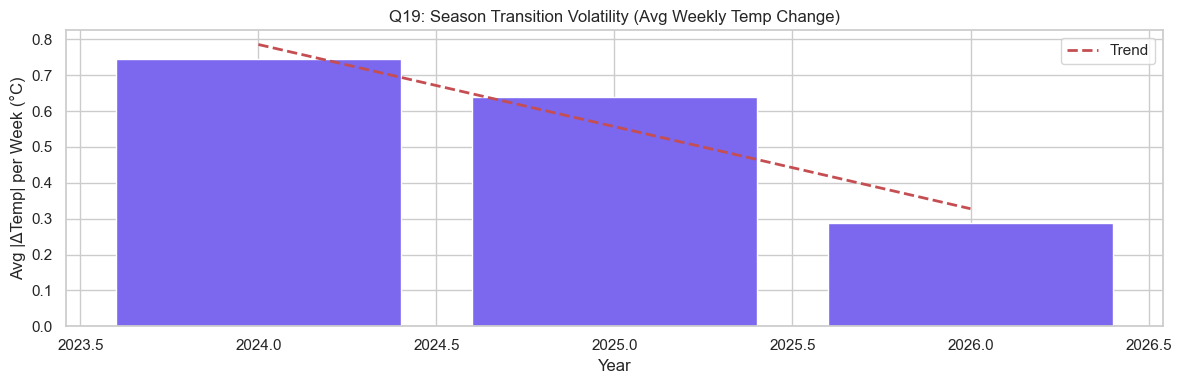

In [22]:
weekly_avg = df.groupby(['year', 'week'])[temp_col].mean().reset_index()
weekly_avg = weekly_avg.sort_values(['year','week'])
weekly_avg['temp_change'] = weekly_avg.groupby('year')[temp_col].diff().abs()

# Transition weeks: approx weeks 8-14 (Winter→Spring) and 36-42 (Summer→Autumn)
transition = weekly_avg[weekly_avg['week'].between(8, 14) | weekly_avg['week'].between(36, 42)]
volatility_by_year = transition.groupby('year')['temp_change'].mean().reset_index()
volatility_by_year.columns = ['year', 'avg_weekly_temp_change']

print('=== Q19: Season Transition Volatility by Year ===')
print(volatility_by_year.round(3).to_string(index=False))

sl, ic, r, p, se = linregress(volatility_by_year['year'], volatility_by_year['avg_weekly_temp_change'])
print(f'\nTrend slope: {sl:.4f} | p-value: {p:.4f}')
print(f'Trend: {"Transition volatility INCREASING ↑" if sl > 0 else "Decreasing ↓"}')

plt.figure(figsize=(12, 4))
plt.bar(volatility_by_year['year'], volatility_by_year['avg_weekly_temp_change'], color='mediumslateblue')
trend_line = sl * volatility_by_year['year'] + ic
plt.plot(volatility_by_year['year'], trend_line, 'r--', lw=2, label='Trend')
plt.title('Q19: Season Transition Volatility (Avg Weekly Temp Change)')
plt.ylabel('Avg |ΔTemp| per Week (°C)')
plt.xlabel('Year')
plt.legend()
plt.tight_layout()
plt.show()

=== Q20: Global Diurnal Temperature Range Trend ===
Slope: -0.0526 °C/year | p = 0.1796
Trend: DTR NARROWING (warming nights) ↓

DTR vs Humidity correlation: r = -0.0657, p = 0.3424


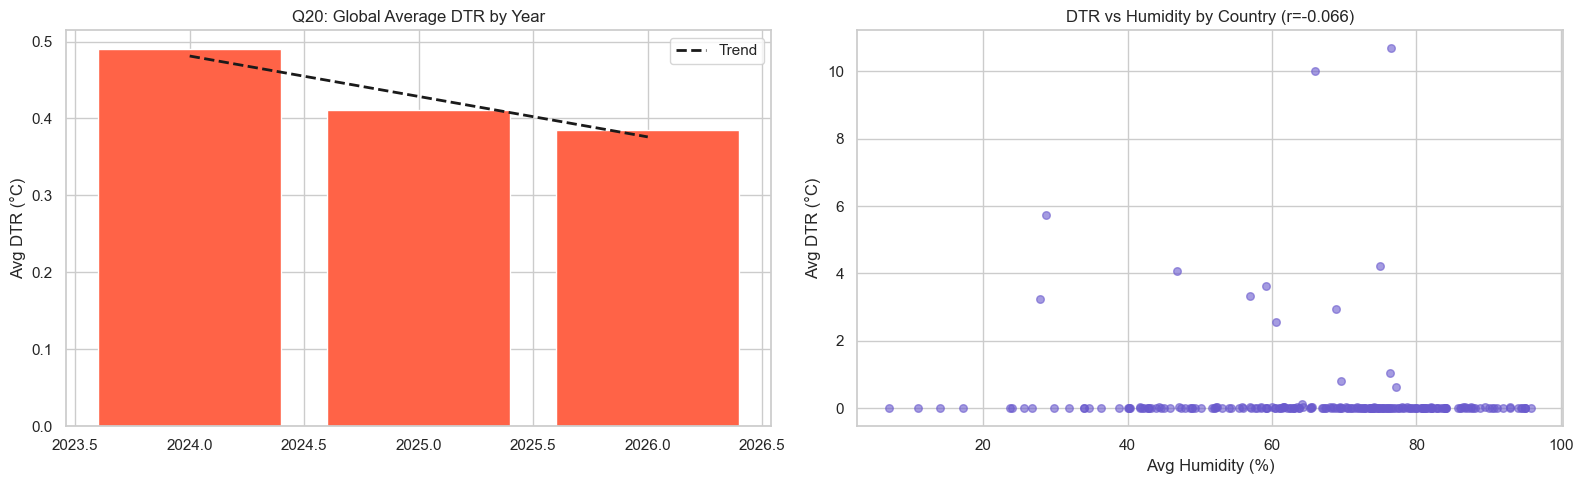

In [23]:
yearly_dtr = df.groupby('year')['diurnal_range'].mean().reset_index()
yearly_dtr.columns = ['year', 'avg_dtr']
yearly_dtr = yearly_dtr.dropna()

sl2, ic2, r2, p2, _ = linregress(yearly_dtr['year'], yearly_dtr['avg_dtr'])
print(f'=== Q20: Global Diurnal Temperature Range Trend ===')
print(f'Slope: {sl2:.4f} °C/year | p = {p2:.4f}')
print(f'Trend: {"DTR NARROWING (warming nights) ↓" if sl2 < 0 else "DTR widening ↑"}')

# Correlate DTR with humidity
dtr_humid = df.groupby('country').agg(avg_dtr=('diurnal_range','mean'),
                                       avg_humid=(humid_col,'mean')).dropna()
r_dh, p_dh = pearsonr(dtr_humid['avg_dtr'], dtr_humid['avg_humid'])
print(f'\nDTR vs Humidity correlation: r = {r_dh:.4f}, p = {p_dh:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(yearly_dtr['year'], yearly_dtr['avg_dtr'], color='tomato')
trend2 = sl2 * yearly_dtr['year'] + ic2
axes[0].plot(yearly_dtr['year'], trend2, 'k--', lw=2, label='Trend')
axes[0].set_title('Q20: Global Average DTR by Year')
axes[0].set_ylabel('Avg DTR (°C)')
axes[0].legend()

axes[1].scatter(dtr_humid['avg_humid'], dtr_humid['avg_dtr'], alpha=0.6, s=30, color='slateblue')
axes[1].set_xlabel('Avg Humidity (%)')
axes[1].set_ylabel('Avg DTR (°C)')
axes[1].set_title(f'DTR vs Humidity by Country (r={r_dh:.3f})')
plt.tight_layout()
plt.show()

=== Q21: Heat Wave Persistence ===
Slope: -32.4369 records/year | p = 0.3843
Trend: Decreasing ↓


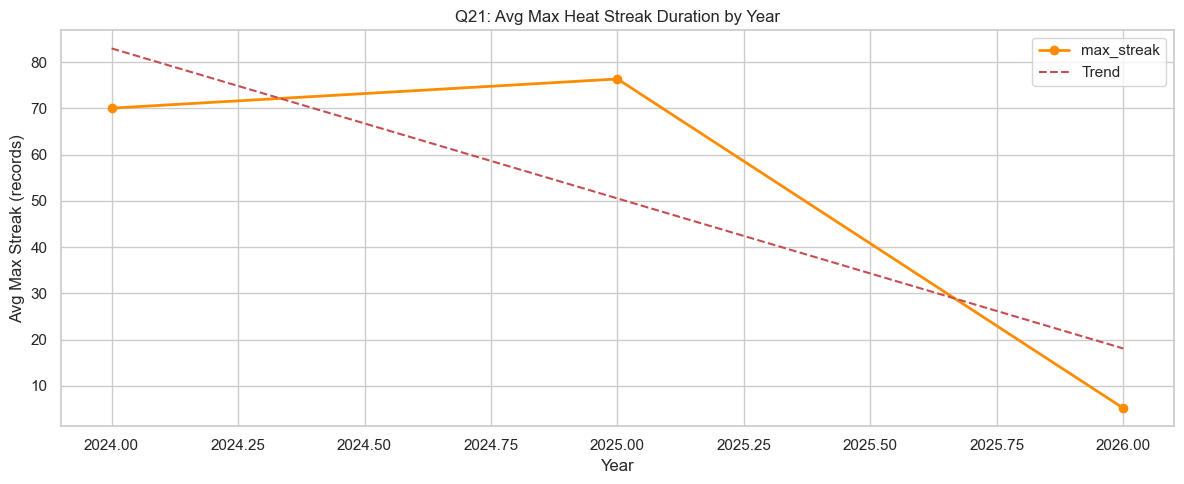

In [24]:
# Per-country mean temperature
country_means = df.groupby('country')[temp_col].mean()
df['above_mean'] = df.apply(lambda row: 1 if row[temp_col] > country_means.get(row['country'], row[temp_col]) else 0, axis=1)

def max_streak(series):
    max_s, cur_s = 0, 0
    for v in series:
        cur_s = cur_s + 1 if v == 1 else 0
        max_s = max(max_s, cur_s)
    return max_s

df_s = df.sort_values([date_col])
yearly_streak = df_s.groupby(['country','year'])['above_mean'].apply(max_streak).reset_index()
yearly_streak.columns = ['country','year','max_streak']
global_streak = yearly_streak.groupby('year')['max_streak'].mean().reset_index()

sl3, ic3, r3, p3, _ = linregress(global_streak['year'], global_streak['max_streak'])
print(f'=== Q21: Heat Wave Persistence ===')
print(f'Slope: {sl3:.4f} records/year | p = {p3:.4f}')
print(f'Trend: {"Streaks INCREASING (more persistent heat) ↑" if sl3 > 0 else "Decreasing ↓"}')

global_streak.plot(x='year', y='max_streak', marker='o', color='darkorange', lw=2)
plt.plot(global_streak['year'], sl3 * global_streak['year'] + ic3, 'r--', label='Trend')
plt.title('Q21: Avg Max Heat Streak Duration by Year')
plt.ylabel('Avg Max Streak (records)')
plt.xlabel('Year')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features_clust = [temp_col, humid_col, precip_col, wind_col, pressure_col]
features_clust = [c for c in features_clust if c in df.columns]

# Compute early and late period profiles
years_sorted = sorted(df['year'].dropna().unique())
mid = years_sorted[len(years_sorted)//2]

early = df[df['year'] <= mid].groupby('country')[features_clust].mean()
late  = df[df['year'] >  mid].groupby('country')[features_clust].mean()
common = early.index.intersection(late.index)
early, late = early.loc[common].dropna(), late.loc[common].dropna()
common = early.index.intersection(late.index)
early, late = early.loc[common], late.loc[common]

scaler = StandardScaler()
early_scaled = scaler.fit_transform(early)
late_scaled  = scaler.transform(late)

n_clusters = 5
km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
early_labels = km.fit_predict(early_scaled)
late_labels  = km.predict(late_scaled)

changed = common[early_labels != late_labels]
print(f'=== Q22: Countries That Changed Climate Cluster (Before vs After {mid}) ===')
print(f'Total shifted: {len(changed)} out of {len(common)}')
print('Countries:', list(changed[:30]))

change_df = pd.DataFrame({'country': common,
                           'early_cluster': early_labels,
                           'late_cluster': late_labels})
change_df['shifted'] = (change_df['early_cluster'] != change_df['late_cluster']).astype(int)
print(change_df[change_df['shifted']==1].head(20).to_string(index=False))

=== Q22: Countries That Changed Climate Cluster (Before vs After 2025) ===
Total shifted: 86 out of 186
Countries: ['Afghanistan', 'Albania', 'Algeria', 'Argentina', 'Australia', 'Bahrain', 'Bangladesh', 'Belgium', 'Bhutan', 'Bosnia and Herzegovina', 'Burundi', 'Cambodia', 'China', 'Costa Rica', 'Cuba', 'Cyprus', 'Denmark', 'Djibouti', 'Ecuador', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'France', 'Gambia', 'Greece', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Iceland', 'India']
               country  early_cluster  late_cluster  shifted
           Afghanistan              1             3        1
               Albania              3             0        1
               Algeria              3             2        1
             Argentina              3             0        1
             Australia              3             1        1
               Bahrain              1             3        1
            Bangladesh              4             1        1
               Belgium             

=== Q23: Most Unpredictable Countries (Highest Weather Standard Deviation) ===
              temperature_celsius  humidity  precip_mm  wind_kph  pressure_mb  composite_variability
country                                                                                             
Burundi                      3.03     13.88       0.30    117.24         2.36                  27.36
Iran                        11.72     19.35       0.21      8.15        56.41                  19.17
Honduras                     2.47      8.13       0.38      2.61        78.85                  18.49
Kazakhstan                  14.65     22.26       0.25      8.36        10.64                  11.23
Mongolia                    16.07     22.67       0.28      5.57         9.44                  10.81
China                       11.12     24.84       0.36      6.55        10.63                  10.70
Kyrghyzstan                 11.92     25.92       0.41      5.54         9.22                  10.60
Turkmenistan

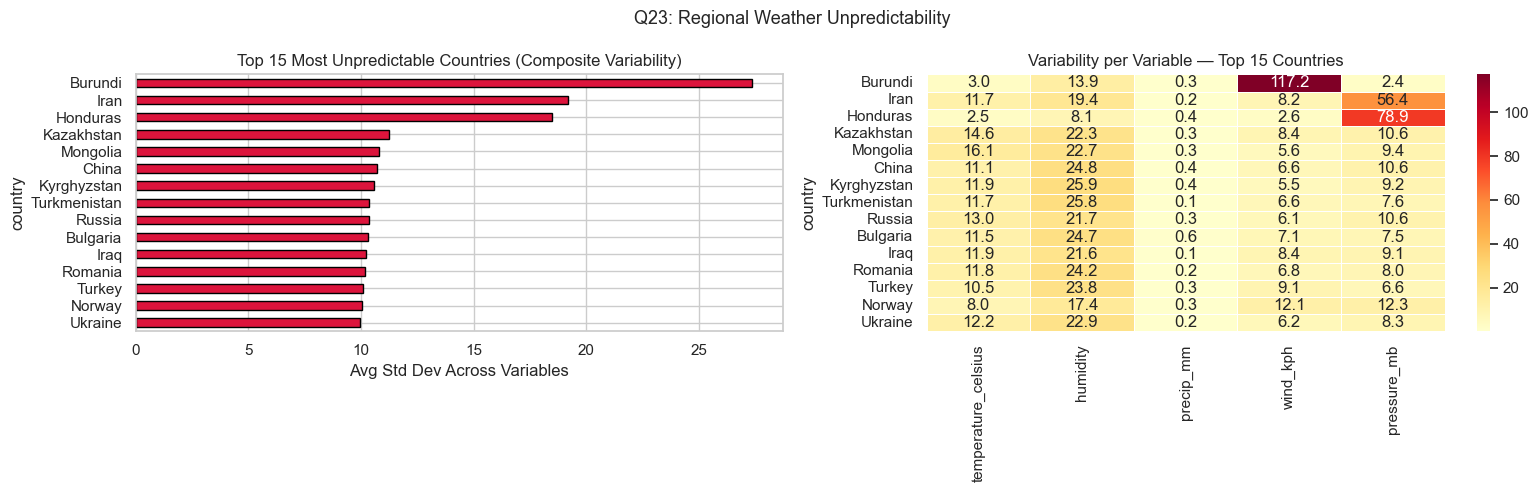


✅ Analysis Complete — All 23 Questions Answered!


In [27]:
variability = df.groupby('country')[features_clust].std()
variability['composite_variability'] = variability.mean(axis=1)  # composite score
variability = variability.sort_values('composite_variability', ascending=False)

print('=== Q23: Most Unpredictable Countries (Highest Weather Standard Deviation) ===')
print(variability.head(15).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

variability['composite_variability'].head(15).plot(
    kind='barh', ax=axes[0], color='crimson', edgecolor='black')
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Most Unpredictable Countries (Composite Variability)')
axes[0].set_xlabel('Avg Std Dev Across Variables')

# Heatmap of std devs
sns.heatmap(variability[features_clust].head(15), cmap='YlOrRd', annot=True, fmt='.1f',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Variability per Variable — Top 15 Countries')

plt.suptitle('Q23: Regional Weather Unpredictability', fontsize=13)
plt.tight_layout()
plt.show()

print('\n✅ Analysis Complete — All 23 Questions Answered!')